# 09 Pendulum ODE with Runge Kutte Integration

We saw in the previous lecture that a straightforward integration of the pendulum equation was possible. More sophisticated solvers follow essentially the same idea, but calculate the "steps" more carefully. Here we will follow NR chapter 17 (which the following figures and equations are copied from).

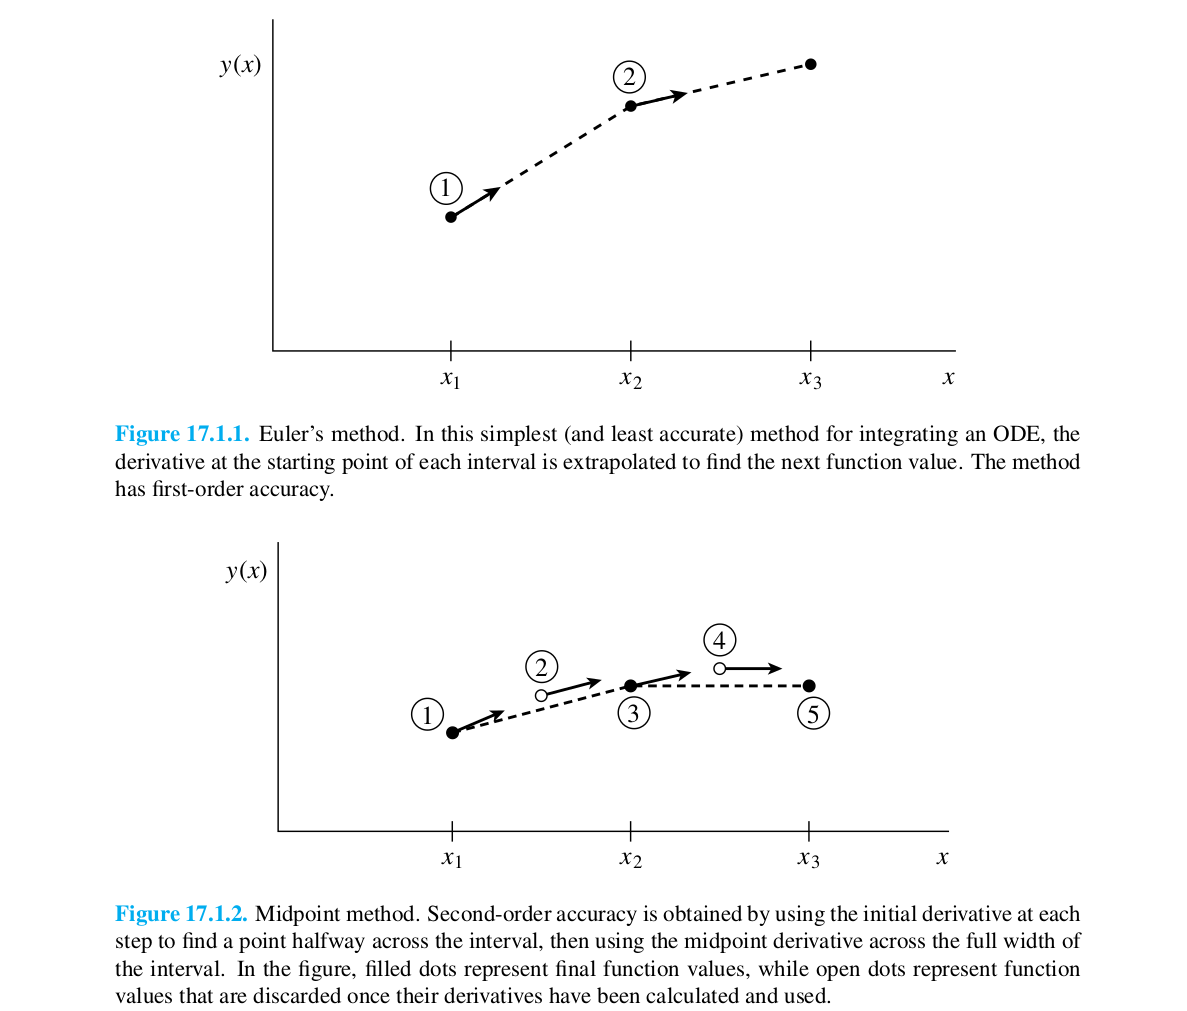



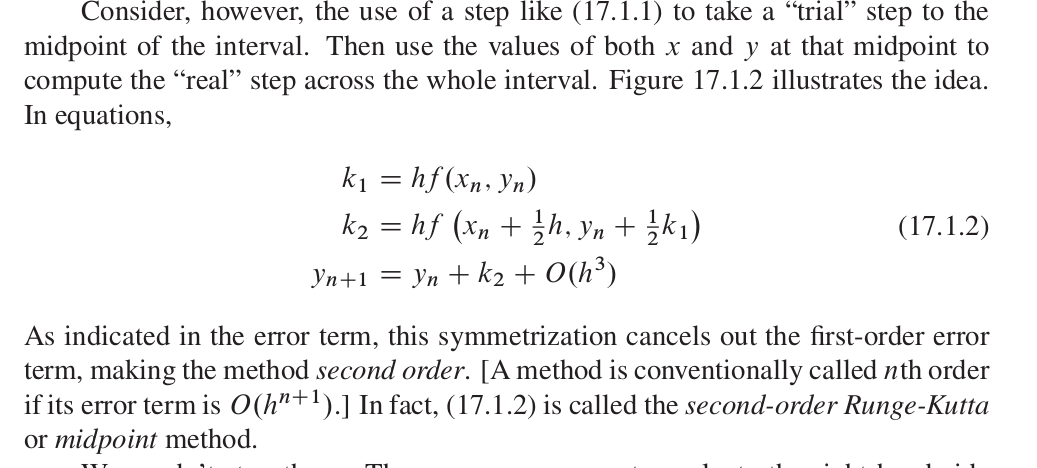

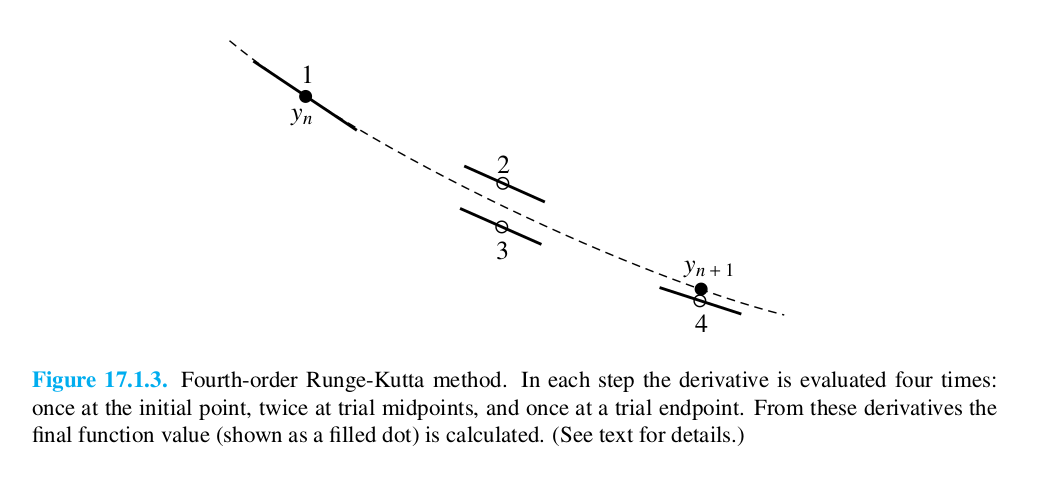

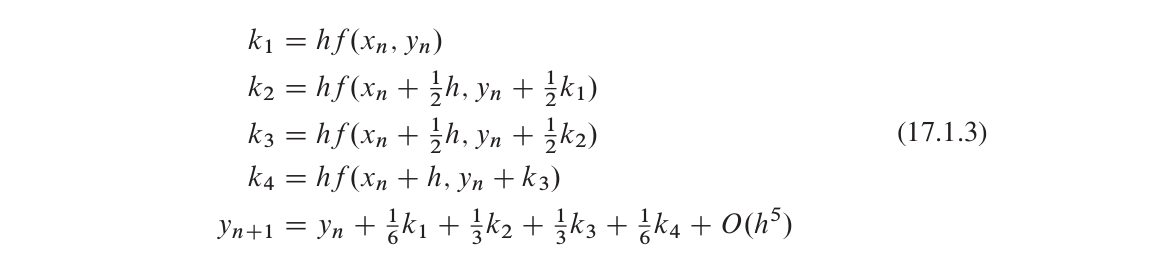



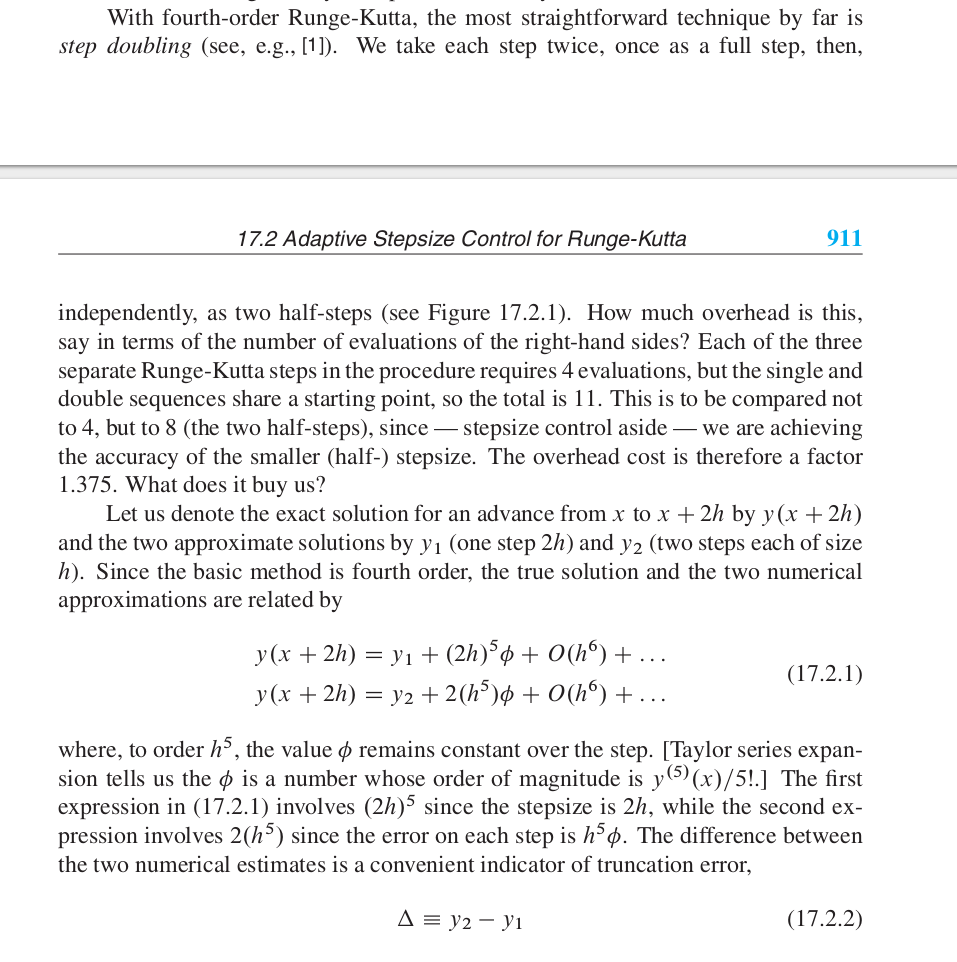



Following this general idea, people have come up with explicit formulas which maximize precision and allow you to calculate the function at fewer places.  Note, however, that all schemes work well for smooth functions- but Taylor series rely on derivatives being defined and continuous to work.  That is usually the case in Physics, but there are times (like when you use MC generated data) that functions are provided in an explicitly discrete form.  

NR also adds **Dense Output** (section 17.2.2) to the mix.  

NR recommends using the "Dormand Prince" embedded method DOPR853 as a generic ODE solver.  

We also add **Adaptive Stepsize Control** so that one calculates the steps close together when the derivatives are large and far apart when they ware small.

neval= 5054


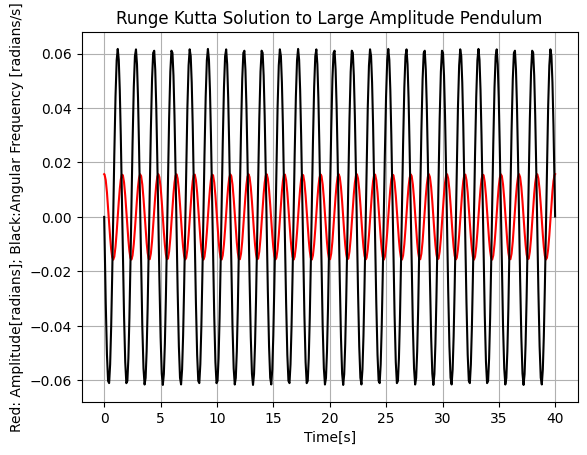

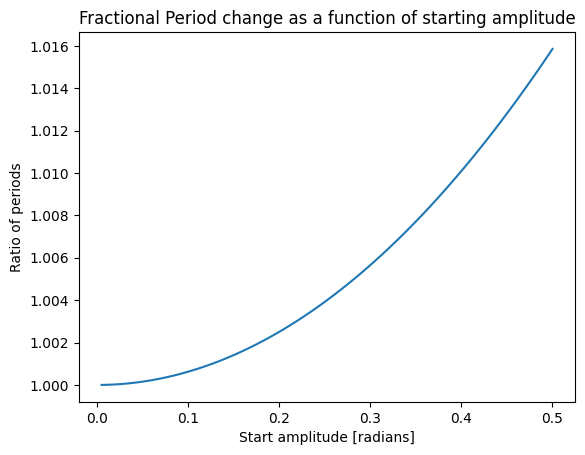

In [24]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.integrate import solve_ivp

neval=0

def pend(t,y):
    global neval
    theta, omega = y
    dydt = np.array([omega, - g/l*np.sin(theta)])
    neval=neval+1
    return dydt

#and now we set up some constants (measured quantities)
l=0.635 #length of pendulum, meters
g=9.8 # acceleration of gravity on Earth's surface, meters/s**2
omega_0=np.sqrt(g/l)
T=2*np.pi/omega_0  #  period, seconds
theta_0=np.pi*.1/20.

#use y0 for the initial conditions
y0 = np.array([theta_0, 0.0])
    
#    We generate a solution 1001 evenly spaced samples in the interval
#    0 <= `t` <= 10.  So our array of times is:

t = np.linspace(0, 25*T, 1001)
    
###    Call `solve_ivp` to generate the solution. 
meth='DOP853'
#meth='RK45' #default, but why??
solrk = solve_ivp(pend,(0,25*T),y0,rtol=1e-11,atol=1e-11,method=meth)
print('neval=',neval)
plt.plot(solrk.t, solrk.y[0,:], 'r')
plt.plot(solrk.t, solrk.y[1,:], 'k')
plt.title("Runge Kutta Solution to Large Amplitude Pendulum")
plt.xlabel('Time[s]')
plt.ylabel('Red: Amplitude[radians]; Black:Angular Frequency [radians/s]')
plt.grid()
plt.show()

from scipy.optimize import root

theta_0=np.pi*.1/20.
theta=np.linspace(0.005,0.5, 99)
period=[]
for th in theta:
    y0 = np.array([th, 0.0])
    solrk = solve_ivp(pend,(0,25*T),y0,rtol=1e-11,atol=1e-11,dense_output=True,method=meth)
    period.append(root(lambda t:solrk.sol(t)[1],1.0*T).x/T)
period=np.array(period)
plt.plot(theta,period)
plt.title("Fractional Period change as a function of starting amplitude")
plt.xlabel("Start amplitude [radians]")
plt.ylabel("Ratio of periods")
plt.show()


Notice!  ~28000 evaluations- versus tens of millions.  

The period changes- we have fewer cycles than 25.  

How well do we do when we check the derivative calculation?

Check this with different numbers of events in the output space.  Also notice that increasing the number of output points doesn't affect the number of evaluations.

To calculate the change in period as a function of amplitude, we use the dense_output option, combined with "root".  
Thus:

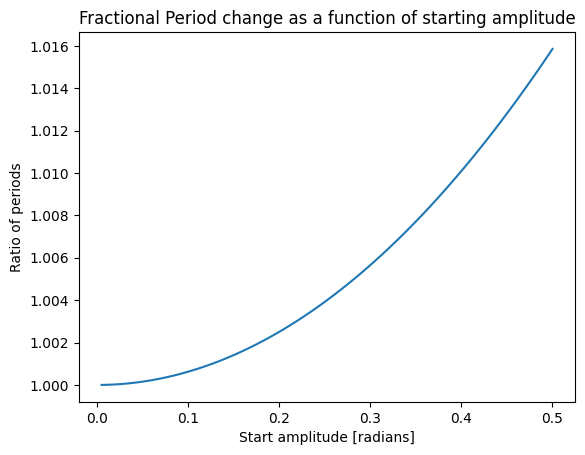

In [25]:
from scipy.optimize import root

theta_0=np.pi*.1/20.
theta=np.linspace(0.005,0.5, 99)
period=[]
for th in theta:
    y0 = np.array([th, 0.0])
    solrk = solve_ivp(pend,(0,25*T),y0,rtol=1e-11,atol=1e-11,dense_output=True,method=meth)
    period.append(root(lambda t:solrk.sol(t)[1],1.0*T).x/T)
period=np.array(period)
plt.plot(theta,period)
plt.title("Fractional Period change as a function of starting amplitude")
plt.xlabel("Start amplitude [radians]")
plt.ylabel("Ratio of periods")
plt.show()

# Validation 1:  Numerical derivative versus equation

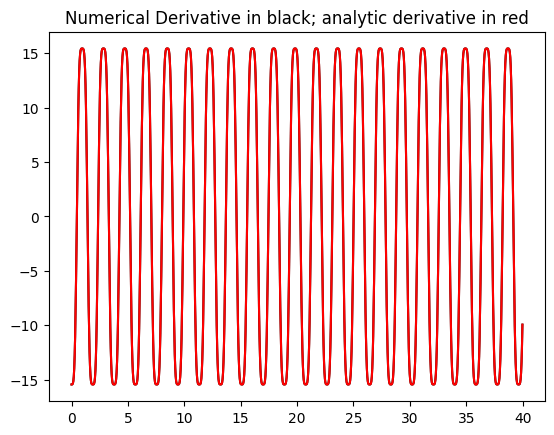

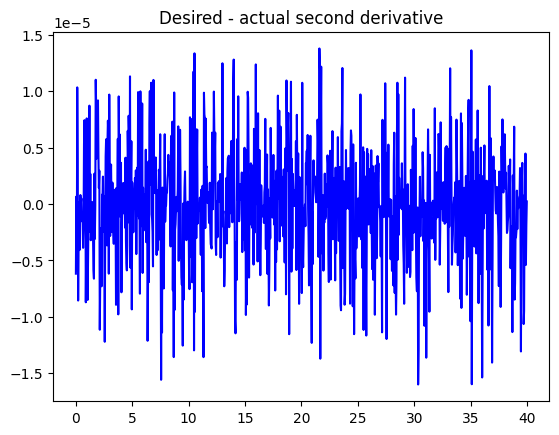

In [26]:
y0 = np.array([np.pi/2, 0.0])
solrk = solve_ivp(pend,(0,25*T),y0,rtol=1e-11,atol=1e-11,dense_output=True,method=meth)

def deriv(y,t):
    tPlus=t+5e-6
    tMinus=t-5e-6
    return (y(tPlus)-y(tMinus))/(tPlus-tMinus)

def doublederiv(y,t):
    tPlus=t+5e-6
    tMinus=t-5e-6
    return ((y(tPlus)-y(t))/(tPlus-t)-(y(t)-y(tMinus))/(t-tMinus))*2.0/(tPlus-tMinus)

thetaDot= deriv(lambda t:solrk.sol(t)[0],t)

thetaDotDot=doublederiv(lambda t:solrk.sol(t)[0],t)
factor=1

plt.plot(t[::factor],thetaDotDot[::factor],'k')
plt.plot(t[::factor],-g/l*np.sin(solrk.sol(t)[0]),'r')
plt.title("Numerical Derivative in black; analytic derivative in red")
plt.show()

diff=thetaDotDot[::factor]+g/l*np.sin(solrk.sol(t)[0])
plt.plot(t[::factor],diff,'b')
plt.title("Desired - actual second derivative")
plt.show()

# Validation 2: time reversal

In [27]:
# recalculate
y0 = np.array([np.pi/2, 0.0])
tlist=np.linspace(0,25*T,500)
solrk = solve_ivp(pend,(0,25*T),y0,t_eval=tlist,rtol=1e-11,atol=1e-11,method=meth)
solrev = solve_ivp(pend,(25*T,0),solrk.y[:,-1],t_eval=tlist[::-1],rtol=1e-11,atol=1e-11,method=meth)
print(solrev.y[:,-1],solrev.t[-1],np.pi/2)

[1.57079633e+00 3.09640547e-09] 0.0 1.5707963267948966


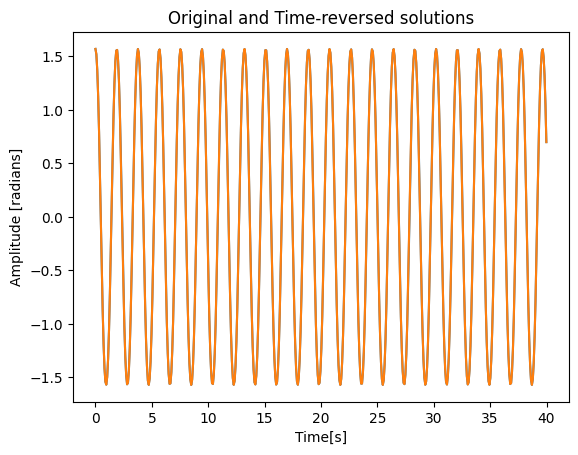

In [28]:
plt.plot(solrk.t, solrk.y[0,:])
plt.plot(solrev.t,solrev.y[0,:])
plt.title("Original and Time-reversed solutions")
plt.xlabel("Time[s]")
plt.ylabel("Amplitude [radians]")
plt.show()

Text(0, 0.5, 'Amplitude [radians]')

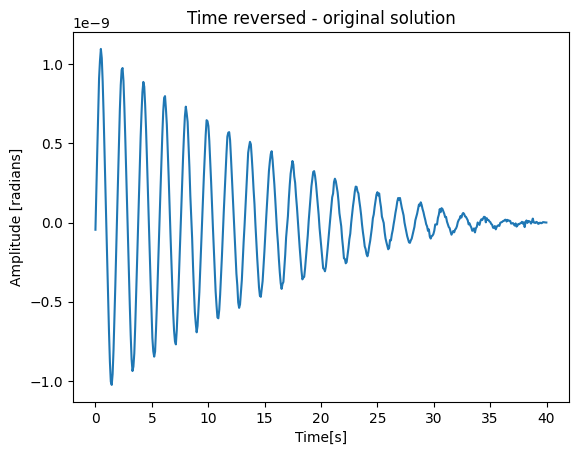

In [29]:
plt.plot(solrev.t,solrev.y[0,:]-solrk.y[0,::-1])
plt.title("Time reversed - original solution")
plt.xlabel("Time[s]")
plt.ylabel("Amplitude [radians]")

# Validation 3:  Conservation of Energy

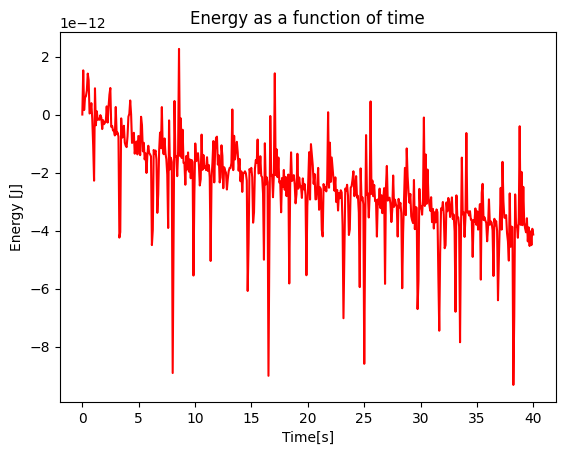

In [30]:
m=0.027 # kg, mass of pendulum
Energy=(0.5*m*l**2)*solrk.y[1,:]**2-(m*g*l)*np.cos(solrk.y[0,:])
plt.plot(solrk.t,Energy,'r')
plt.title("Energy as a function of time")
plt.xlabel("Time[s]")
plt.ylabel("Energy [J]")
plt.show()
#print('Energy is', Energy)